# Performance Tuning V8 — Legal-BERT Fine-Tune (Colab GPU)

**Goal:** Push micro-F1 past 0.85 by fine-tuning Legal-BERT on 512-token chunks and max-pooling to contract level.

**Baseline (from CPU ablation in `performance_tuning.ipynb`):**
- V1 TF-IDF + LR: 0.7936
- V5 (best CPU): 0.8020 (TF-IDF + calibration + per-clause thresholds)
- V6/V7 (MiniLM ensembles): regressed — dense embeddings can't beat TF-IDF with only 408 train contracts

**This notebook:**
1. Mount repo / install deps
2. Load CUAD, filter clauses, chunk with Legal-BERT tokenizer (stride=128)
3. Fine-tune `nlpaueb/legal-bert-base-uncased` for 4 epochs on T4
4. Max-pool chunk probabilities → contract-level scores
5. Tune per-clause thresholds on val, report metrics
6. Save artifacts for the webapp and update the ablation table

**Wall time target:** ~20-25 min on T4, ~8-12 min on A100.

## Section 0 — Colab setup

Uncomment the Colab-only cells when running on Colab. If running locally on a machine with a CUDA GPU, skip them.

In [1]:
# Colab: install deps (skip locally — handled by requirements.txt)
# !pip install -q "transformers>=4.36,<4.45" "datasets>=2.14" "accelerate>=0.26" scikit-learn joblib huggingface_hub

In [6]:

# Colab: mount Drive and cd into the project checkout
from google.colab import drive
drive.mount('/content/drive')

# IMPORTANT: Adjust this path to your actual repo location in Google Drive
%cd /content/drive/MyDrive/BT5153/crazy-tharp-7c055d

import os, sys
print('cwd:', os.getcwd())
print('python:', sys.version.split()[0])


Mounted at /content/drive
[Errno 2] No such file or directory: '/content/drive/MyDrive/BT5153/crazy-tharp-7c055d'
/content
cwd: /content
python: 3.12.13


In [3]:
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM (GB):', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))
else:
    print('WARNING: no GPU detected — this notebook will be extremely slow on CPU')

CUDA available: True
GPU: Tesla T4
VRAM (GB): 15.6


In [4]:
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Section 1 — Load CUAD, filter, chunk

We reuse `prepare_chunked_splits`, which internally:
- builds clause↔id mappings
- splits contracts with seed=42 (same split as V1-V7, so V8 is directly comparable)
- tokenizes each contract into overlapping 512-token chunks (stride=128) with the **Legal-BERT tokenizer**
- propagates the contract's multi-label vector to every chunk that overlaps a labelled span

In [7]:
# ── Colab-only: mount Drive, download CUAD, cache parquet ─────────────────────
# Run this ONCE. On subsequent runs it's a no-op (hits the cached files).

from google.colab import drive
drive.mount('/content/drive')

!pip install -q huggingface_hub

from __future__ import annotations
import json, os
from pathlib import Path
from typing import Any

import pandas as pd
from huggingface_hub import hf_hub_download

# Point this wherever you want the data to live on Drive
DRIVE_DATA_DIR = Path('/content/drive/MyDrive/BT5153/data/cuad')
DRIVE_DATA_DIR.mkdir(parents=True, exist_ok=True)


def _parse_cuad_json(cuad: dict[str, Any]) -> pd.DataFrame:
    rows = []
    for doc in cuad['data']:
        for paragraph in doc['paragraphs']:
            context = paragraph['context']
            for qa in paragraph['qas']:
                answers = qa.get('answers', [])
                rows.append({
                    'contract_title': doc['title'],
                    'clause_type':    qa['id'].split('__', 1)[-1],
                    'question':       qa['question'],
                    'contract_text':  context,
                    'has_answer':     bool(len(answers) > 0),
                    'answer_texts':   [a['text'] for a in answers],
                    'answer_starts':  [a['answer_start'] for a in answers],
                    'answer_count':   len(answers),
                })
    return pd.DataFrame(rows)


def load_cuad(data_dir: str | Path = DRIVE_DATA_DIR) -> pd.DataFrame:
    data_dir = Path(data_dir)
    raw_json_path = data_dir / 'CUAD_v1' / 'CUAD_v1.json'
    parquet_path  = data_dir / 'cuad_qa_rows.parquet'
    raw_json_path.parent.mkdir(parents=True, exist_ok=True)

    # Fast path: parquet already cached
    if parquet_path.exists():
        df = pd.read_parquet(parquet_path)
        print(f'CUAD loaded from cache ({parquet_path}): {df["contract_title"].nunique():,} contracts, '
              f'{df["clause_type"].nunique()} clause types, {len(df):,} rows')
        return df

    # Download raw JSON if needed
    if not raw_json_path.exists():
        print(f'Downloading CUAD_v1.json to {raw_json_path} ...')
        downloaded = hf_hub_download(
            repo_id='theatticusproject/cuad',
            repo_type='dataset',
            filename='CUAD_v1/CUAD_v1.json',
            local_dir=str(data_dir),
        )
        raw_json_path = Path(downloaded)

    with raw_json_path.open() as f:
        cuad = json.load(f)

    df = _parse_cuad_json(cuad)
    df.to_parquet(parquet_path, index=False)
    print(f'CUAD parsed + cached to {parquet_path}: {df["contract_title"].nunique():,} contracts, '
          f'{df["clause_type"].nunique()} clause types, {len(df):,} rows, '
          f'positive rate {df["has_answer"].mean():.2%}')
    return df


# ── Download + cache now ──────────────────────────────────────────────────────
cuad_df = load_cuad()
cuad_df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


CUAD_v1/CUAD_v1.json:   0%|          | 0.00/40.1M [00:00<?, ?B/s]

CUAD parsed + cached to /content/drive/MyDrive/BT5153/data/cuad/cuad_qa_rows.parquet: 510 contracts, 41 clause types, 20,910 rows, positive rate 32.05%


,contract_title,clause_type,question,contract_text,has_answer,answer_texts,answer_starts,answer_count
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,True,[DISTRIBUTOR AGREEMENT],[44],1
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,True,"[Distributor, Electric City Corp., Electric Ci...","[244, 148, 49574, 197, 212]",5
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Agreement Date,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...,True,"[7th day of September, 1999.]",[263],1


In [9]:
from __future__ import annotations

from collections import defaultdict
from typing import Any

import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import AutoTokenizer


# ── Clause filtering ──────────────────────────────────────────────────────────

def filter_clauses(
    cuad_df: pd.DataFrame,
    min_positives: int = 20,
) -> tuple[pd.DataFrame, dict[str, int]]:
    """Drop clause types with fewer than min_positives positive examples.

    Returns (filtered_df, excluded_dict) where excluded_dict maps
    clause_type → positive_count for every excluded type.
    """
    positive_counts = (
        cuad_df[cuad_df["has_answer"]]
        .groupby("clause_type")
        .size()
    )
    excluded = {
        clause: int(count)
        for clause, count in positive_counts.items()
        if count < min_positives
    }
    # Also exclude clause types with zero positives (not in positive_counts at all)
    all_types = set(cuad_df["clause_type"].unique())
    for clause in all_types:
        if clause not in positive_counts.index:
            excluded[clause] = 0

    keep = all_types - set(excluded.keys())
    filtered = cuad_df[cuad_df["clause_type"].isin(keep)].copy()

    if excluded:
        print(f"Excluded {len(excluded)} clause types (below min_positives={min_positives}):")
        for c, n in sorted(excluded.items(), key=lambda x: x[1]):
            print(f"  {c}: {n} positives")

    return filtered, excluded


def plot_clause_frequency(cuad_df: pd.DataFrame, save_path: str | None = None) -> pd.DataFrame:
    """Bar chart: positive rate per clause type, sorted descending."""
    import matplotlib.pyplot as plt
    import seaborn as sns
    summary = (
        cuad_df.groupby("clause_type")["has_answer"]
        .agg(positive_rate="mean", positive_count="sum", total="count")
        .sort_values("positive_rate", ascending=False)
        .reset_index()
    )
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.barplot(data=summary, x="positive_rate", y="clause_type", ax=ax, palette="crest")
    ax.set_title("Positive Rate per Clause Type (CUAD)")
    ax.set_xlabel("Positive Rate")
    ax.set_ylabel("")
    ax.axvline(x=0.2, color="red", linestyle="--", alpha=0.6, label="20% threshold")
    ax.legend()
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    else:
        plt.show()
    return summary


# ── Clause mappings ───────────────────────────────────────────────────────────

def build_clause_mappings(cuad_df: pd.DataFrame) -> tuple[dict[str, int], dict[int, str]]:
    """Build bidirectional clause name ↔ integer ID mappings."""
    clause_names = sorted(cuad_df["clause_type"].unique().tolist())
    clause_to_id = {name: idx for idx, name in enumerate(clause_names)}
    id_to_clause = {idx: name for name, idx in clause_to_id.items()}
    return clause_to_id, id_to_clause


# ── Contract record building ──────────────────────────────────────────────────

def build_contract_records(cuad_df: pd.DataFrame) -> list[dict[str, Any]]:
    """Aggregate clause answer spans per contract into a list of contract records."""
    records: list[dict[str, Any]] = []
    for contract_title, group in cuad_df.groupby("contract_title", sort=False):
        contract_text = group["contract_text"].iloc[0]
        clause_spans: dict[str, list[tuple[int, int]]] = defaultdict(list)
        for row in group.itertuples(index=False):
            for answer_text, answer_start in zip(row.answer_texts, row.answer_starts):
                answer_end = int(answer_start) + len(answer_text)
                clause_spans[row.clause_type].append((int(answer_start), answer_end))
        records.append({
            "contract_title": contract_title,
            "contract_text": contract_text,
            "clause_spans": dict(clause_spans),
        })
    return records


def split_contract_records(
    contract_records: list[dict[str, Any]],
    train_size: float = 0.8,
    val_size: float = 0.1,
    test_size: float = 0.1,
    seed: int = 42,
) -> tuple[list, list, list]:
    """Split contract records into train/val/test sets at the contract level."""
    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("train_size + val_size + test_size must sum to 1.0")
    titles = [r["contract_title"] for r in contract_records]
    title_to_record = {r["contract_title"]: r for r in contract_records}
    train_titles, temp_titles = train_test_split(titles, train_size=train_size, random_state=seed)
    val_ratio = val_size / (val_size + test_size)
    val_titles, test_titles = train_test_split(temp_titles, train_size=val_ratio, random_state=seed)
    return (
        [title_to_record[t] for t in train_titles],
        [title_to_record[t] for t in val_titles],
        [title_to_record[t] for t in test_titles],
    )


def sample_contracts(
    contract_records: list[dict[str, Any]],
    frac: float = 1.0,
    seed: int = 42,
) -> list[dict[str, Any]]:
    """Return a reproducible random sample of ``frac`` of the given contract records.

    Sampling is performed *before* the train/val/test split so every split
    receives a proportional share of the reduced pool.  The methodology
    (chunking, label assignment, split ratios) is identical to the full run —
    only the number of contracts changes.

    Args:
        contract_records: Full list of contract records.
        frac: Fraction of contracts to keep (0 < frac <= 1.0).
        seed: Random seed for reproducibility.

    Returns:
        Shuffled-and-subsampled list of contract records.
    """
    if frac >= 1.0:
        return contract_records
    n = max(1, round(len(contract_records) * frac))
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(contract_records), size=n, replace=False)
    sampled = [contract_records[i] for i in sorted(indices)]
    print(f"sample_contracts: using {n}/{len(contract_records)} contracts ({frac:.0%})")
    return sampled


# ── Chunk examples ────────────────────────────────────────────────────────────

def _span_overlaps_chunk(span_start: int, span_end: int, chunk_start: int, chunk_end: int) -> bool:
    return max(span_start, chunk_start) < min(span_end, chunk_end)


def build_chunk_examples(
    contract_records: list[dict[str, Any]],
    clause_to_id: dict[str, int],
    tokenizer: Any,
    max_length: int = 512,
    stride: int = 128,
) -> list[dict[str, Any]]:
    """Tokenize contracts with sliding window and assign multi-label vectors per chunk."""
    chunk_examples: list[dict[str, Any]] = []
    num_labels = len(clause_to_id)

    for record in contract_records:
        contract_text = record["contract_text"]
        chunked = tokenizer(
            contract_text,
            max_length=max_length,
            stride=stride,
            truncation=True,
            padding="max_length",
            return_overflowing_tokens=True,
            return_offsets_mapping=True,
        )
        for chunk_index in range(len(chunked["input_ids"])):
            offset_mapping = chunked["offset_mapping"][chunk_index]
            valid_offsets = [(s, e) for s, e in offset_mapping if e > s]
            if not valid_offsets:
                continue
            chunk_char_start = valid_offsets[0][0]
            chunk_char_end = valid_offsets[-1][1]
            labels = np.zeros(num_labels, dtype=np.float32)
            for clause_name, spans in record["clause_spans"].items():
                if clause_name not in clause_to_id:
                    continue
                clause_id = clause_to_id[clause_name]
                if any(_span_overlaps_chunk(s, e, chunk_char_start, chunk_char_end) for s, e in spans):
                    labels[clause_id] = 1.0
            chunk_example: dict[str, Any] = {
                "contract_title": record["contract_title"],
                "chunk_index": chunk_index,
                "chunk_char_start": chunk_char_start,
                "chunk_char_end": chunk_char_end,
                "chunk_text": contract_text[chunk_char_start:chunk_char_end],
                "input_ids": chunked["input_ids"][chunk_index],
                "attention_mask": chunked["attention_mask"][chunk_index],
                "labels": labels.tolist(),
            }
            if "token_type_ids" in chunked:
                chunk_example["token_type_ids"] = chunked["token_type_ids"][chunk_index]
            chunk_examples.append(chunk_example)
    return chunk_examples


# ── Dataset class ─────────────────────────────────────────────────────────────

class MultiLabelChunkDataset(Dataset):
    """PyTorch Dataset wrapping a list of chunk examples."""

    def __init__(self, chunk_examples: list[dict[str, Any]]) -> None:
        self.chunk_examples = chunk_examples

    def __len__(self) -> int:
        return len(self.chunk_examples)

    def __getitem__(self, index: int) -> dict[str, torch.Tensor]:
        ex = self.chunk_examples[index]
        item = {
            "input_ids": torch.tensor(ex["input_ids"], dtype=torch.long),
            "attention_mask": torch.tensor(ex["attention_mask"], dtype=torch.long),
            "labels": torch.tensor(ex["labels"], dtype=torch.float32),
        }
        if "token_type_ids" in ex:
            item["token_type_ids"] = torch.tensor(ex["token_type_ids"], dtype=torch.long)
        return item


# ── Sample & class weights ────────────────────────────────────────────────────

def compute_sample_weights(
    chunk_examples: list[dict[str, Any]],
    negative_weight: float = 0.1,
) -> list[float]:
    """Per-sample loss weights: all-negative chunks get negative_weight, others get 1.0.

    This is the feature-level downweighting from the CUAD paper — reduces the
    outsized influence of the majority all-negative chunks during training.
    """
    weights = []
    for ex in chunk_examples:
        is_all_negative = all(label_val == 0.0 for label_val in ex["labels"])
        weights.append(negative_weight if is_all_negative else 1.0)
    return weights


def compute_pos_weight(chunk_examples: list[dict[str, Any]]) -> torch.Tensor:
    """Per-label pos_weight tensor for BCEWithLogitsLoss: neg_count / pos_count.

    Tells the loss function to penalise missed positives more heavily for rare labels.
    """
    label_matrix = np.asarray([ex["labels"] for ex in chunk_examples], dtype=np.float32)
    positive_counts = label_matrix.sum(axis=0)
    negative_counts = len(label_matrix) - positive_counts
    weights = np.where(positive_counts > 0, negative_counts / np.maximum(positive_counts, 1.0), 1.0)
    return torch.tensor(weights, dtype=torch.float32)


# ── Contract-level aggregation ────────────────────────────────────────────────

def aggregate_contract_predictions(chunk_long_df: pd.DataFrame) -> pd.DataFrame:
    """Max-probability rollup across chunks per (contract_title, clause_type).

    Input DataFrame must have columns: contract_title, clause_type, score, chunk_index.
    Returns DataFrame with columns: contract_title, clause_type, max_score, best_chunk_index.
    """
    agg = (
        chunk_long_df
        .sort_values("score", ascending=False)
        .groupby(["contract_title", "clause_type"], sort=False)
        .first()
        .rename(columns={"score": "max_score", "chunk_index": "best_chunk_index"})
        .reset_index()
    )
    return agg[["contract_title", "clause_type", "max_score", "best_chunk_index"]]


def build_chunk_to_contract_map(chunk_examples: list[dict[str, Any]]) -> dict[int, str]:
    """Map chunk list index → contract_title for tracing predictions back to contracts."""
    return {i: ex["contract_title"] for i, ex in enumerate(chunk_examples)}


# ── Convenience: prepare all splits ──────────────────────────────────────────

def prepare_chunked_splits(
    cuad_df: pd.DataFrame,
    model_name: str = "bert-base-uncased",
    max_length: int = 512,
    stride: int = 128,
    seed: int = 42,
    sample_frac: float = 1.0,
) -> dict[str, Any]:
    """End-to-end helper: build clause mappings, split contracts, tokenize, return all artifacts.

    Note: call filter_clauses(cuad_df) before passing in if you want to exclude
    low-frequency clause types. This function uses whatever clause types are present in cuad_df.

    Args:
        sample_frac: Fraction of contracts to use (0 < frac <= 1.0).  Values
            below 1.0 invoke ``sample_contracts`` before splitting, giving a
            representative subset that runs proportionally faster.  Set to 1.0
            (default) for the full dataset.
    """
    tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)
    clause_to_id, id_to_clause = build_clause_mappings(cuad_df)
    contract_records = build_contract_records(cuad_df)
    if sample_frac < 1.0:
        contract_records = sample_contracts(contract_records, frac=sample_frac, seed=seed)
    train_records, val_records, test_records = split_contract_records(contract_records, seed=seed)
    train_ex = build_chunk_examples(train_records, clause_to_id, tokenizer, max_length, stride)
    val_ex   = build_chunk_examples(val_records,   clause_to_id, tokenizer, max_length, stride)
    test_ex  = build_chunk_examples(test_records,  clause_to_id, tokenizer, max_length, stride)
    train_sample_weights = compute_sample_weights(train_ex)
    pos_weight_tensor = compute_pos_weight(train_ex)
    return {
        "tokenizer": tokenizer,
        "clause_to_id": clause_to_id,
        "id_to_clause": id_to_clause,
        "train_records": train_records, "val_records": val_records, "test_records": test_records,
        "train_examples": train_ex, "val_examples": val_ex, "test_examples": test_ex,
        "train_dataset": MultiLabelChunkDataset(train_ex),
        "val_dataset":   MultiLabelChunkDataset(val_ex),
        "test_dataset":  MultiLabelChunkDataset(test_ex),
        "train_sample_weights": train_sample_weights,
        "pos_weight": pos_weight_tensor,
    }


In [10]:
# from data_loading import load_cuad
# from preprocessing import filter_clauses, prepare_chunked_splits

cuad_df = load_cuad('/content/drive/MyDrive/BT5153/data/cuad')
cuad_filtered, excluded = filter_clauses(cuad_df, min_positives=20)
print(f'Clauses kept: {cuad_filtered["clause_type"].nunique()} | excluded: {len(excluded)}')

CUAD loaded from cache (/content/drive/MyDrive/BT5153/data/cuad/cuad_qa_rows.parquet): 510 contracts, 41 clause types, 20,910 rows
Excluded 3 clause types (below min_positives=20):
  Source Code Escrow: 13 positives
  Price Restrictions: 15 positives
  Unlimited/All-You-Can-Eat-License: 17 positives
Clauses kept: 38 | excluded: 3


In [11]:
MODEL_NAME = 'nlpaueb/legal-bert-base-uncased'

splits = prepare_chunked_splits(
    cuad_filtered,
    model_name=MODEL_NAME,
    max_length=512,
    stride=128,
    seed=SEED,
)

print(f"Contracts — train: {len(splits['train_records'])}, val: {len(splits['val_records'])}, test: {len(splits['test_records'])}")
print(f"Chunks    — train: {len(splits['train_examples'])}, val: {len(splits['val_examples'])}, test: {len(splits['test_examples'])}")
print(f"Labels    — {len(splits['id_to_clause'])}")

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Contracts — train: 408, val: 51, test: 51
Chunks    — train: 11521, val: 1390, test: 1382
Labels    — 38


## Section 2 — Fine-tune Legal-BERT

Uses the existing `train_legal_bert_cuad` helper, which wraps `train_bert_cuad` and runs the standard CUAD recipe:
- AdamW, lr=2e-5, weight_decay=0.01, linear warmup (10%)
- BCEWithLogitsLoss with per-label `pos_weight` (from `compute_pos_weight`)
- Per-sample downweighting of all-negative chunks (from `compute_sample_weights`)
- Validation logits/labels collected at the end of each epoch; best-epoch model kept

If T4 OOMs at `batch_size=16`, drop to 8 (slower but fits easily).

In [12]:
from __future__ import annotations

import copy
from dataclasses import dataclass, field
from typing import Any

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification, get_linear_schedule_with_warmup

# from preprocessing import MultiLabelChunkDataset, compute_pos_weight, compute_sample_weights


def _tfidf_proba_col(est, X):
    """Return class-1 probability; DummyClassifier may only have one class."""
    proba = est.predict_proba(X)
    if len(est.classes_) == 1:
        return np.full(X.shape[0], float(est.classes_[0]))
    return proba[:, 1]


class _TfIdfPipeline:
    """Wraps a TF-IDF vectorizer + per-label estimators for inference.

    predict_proba returns raw probabilities in [0, 1] — NOT log-odds.
    Convert to log-odds before passing to sigmoid-based evaluation if needed:
        p = np.clip(pipeline.predict_proba(texts), 1e-7, 1-1e-7)
        logits = np.log(p / (1 - p))
    """

    def __init__(self, vec, ests):
        self.vectorizer = vec
        self.estimators_ = ests

    def predict_proba(self, texts: list[str]) -> np.ndarray:
        X = self.vectorizer.transform(texts)
        return np.column_stack([_tfidf_proba_col(e, X) for e in self.estimators_])


@dataclass
class ModelArtifacts:
    """Unified container returned by every training function."""
    model_name: str
    model: Any
    tokenizer: Any
    best_threshold: float
    val_metrics: dict[str, float]
    history: pd.DataFrame
    id_to_clause: dict[int, str]
    val_logits: np.ndarray
    val_labels: np.ndarray


def choose_device() -> torch.device:
    """Select the best available device: CUDA > MPS > CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


def _sigmoid(logits: np.ndarray) -> np.ndarray:
    return 1.0 / (1.0 + np.exp(-np.clip(logits, -500, 500)))


def _tune_global_threshold(
    logits: np.ndarray,
    labels: np.ndarray,
    thresholds: np.ndarray | None = None,
) -> tuple[float, dict[str, float]]:
    """Find the global threshold maximising micro-F1; return (threshold, metrics_dict)."""
    from sklearn.metrics import f1_score, precision_score, recall_score
    if thresholds is None:
        thresholds = np.arange(0.1, 0.91, 0.05)
    best_t = 0.5
    best_f1 = -1.0
    for t in thresholds:
        preds = (_sigmoid(logits) >= t).astype(int)
        f1 = float(f1_score(labels.astype(int), preds, average="micro", zero_division=0))
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    preds = (_sigmoid(logits) >= best_t).astype(int)
    return best_t, {
        "micro_f1":        best_f1,
        "micro_precision": float(precision_score(labels.astype(int), preds, average="micro", zero_division=0)),
        "micro_recall":    float(recall_score(labels.astype(int), preds, average="micro",    zero_division=0)),
    }


def collect_logits_and_labels(
    model: Any,
    dataloader: DataLoader,
    device: torch.device,
    max_batches: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Run inference on a DataLoader and return (logits, labels) as numpy arrays."""
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for i, batch in enumerate(dataloader):
            if max_batches is not None and i >= max_batches:
                break
            labels = batch["labels"].cpu().numpy()
            inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
            logits = model(**inputs).logits.cpu().numpy()
            all_logits.append(logits)
            all_labels.append(labels)
    return np.vstack(all_logits), np.vstack(all_labels)


def _run_training_loop(
    model: Any,
    train_loader: DataLoader,
    val_loader: DataLoader,
    train_examples: list[dict],
    device: torch.device,
    epochs: int = 3,
    learning_rate: float = 2e-5,
    weight_decay: float = 0.01,
    warmup_ratio: float = 0.1,
    max_train_batches: int | None = None,
    max_val_batches: int | None = None,
) -> tuple[Any, pd.DataFrame, float, dict, np.ndarray, np.ndarray]:
    """Shared training loop for all transformer models.

    Returns (model, history_df, best_threshold, best_val_metrics, best_val_logits, best_val_labels).
    Applies pos_weight (BCEWithLogitsLoss) and per-sample downweighting for all-negative chunks.
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
    effective = len(train_loader) if max_train_batches is None else min(len(train_loader), max_train_batches)
    total_steps = max(1, epochs * max(1, effective))
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * warmup_ratio), total_steps)

    pos_weight = compute_pos_weight(train_examples).to(device)
    sample_weights = torch.tensor(compute_sample_weights(train_examples), dtype=torch.float32)
    # reduction="none" so we can apply per-sample weights manually
    loss_fn = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction="none")

    if epochs < 1:
        raise ValueError(f"epochs must be >= 1, got {epochs}")

    # Mixed precision: ~1.5-2x speedup on CUDA (T4/V100/A100). No-op on CPU/MPS.
    use_amp = device.type == "cuda"
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    best_state: dict | None = None
    best_t = 0.5
    best_metrics: dict[str, float] = {"micro_f1": -1.0}
    best_val_logits: np.ndarray | None = None
    best_val_labels: np.ndarray | None = None
    history_rows: list[dict] = []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss, seen = 0.0, 0
        sample_offset = 0  # tracks position in sample_weights across batches

        for bi, batch in enumerate(train_loader):
            if max_train_batches is not None and bi >= max_train_batches:
                break
            labels = batch["labels"].to(device)
            inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
            optimizer.zero_grad(set_to_none=True)

            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = model(**inputs).logits
                # per-sample loss weighting: down-weight all-negative chunks
                batch_size_actual = labels.shape[0]
                batch_sw = sample_weights[sample_offset:sample_offset + batch_size_actual].to(device)
                loss = (loss_fn(logits, labels).mean(dim=1) * batch_sw).mean()

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            total_loss += float(loss.item())
            seen += 1
            sample_offset += batch_size_actual

        val_logits, val_labels = collect_logits_and_labels(model, val_loader, device, max_val_batches)
        t, metrics = _tune_global_threshold(val_logits, val_labels)
        history_rows.append({"epoch": epoch, "train_loss": total_loss / max(1, seen),
                              "val_threshold": t, **metrics})

        if metrics["micro_f1"] > best_metrics["micro_f1"]:
            best_metrics = metrics
            best_t = t
            best_state = copy.deepcopy(model.state_dict())
            best_val_logits = val_logits
            best_val_labels = val_labels

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, pd.DataFrame(history_rows), best_t, best_metrics, best_val_logits, best_val_labels


def train_tfidf_lr(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    id_to_clause: dict[int, str],
) -> ModelArtifacts:
    """TF-IDF + multi-output Logistic Regression baseline (contract-level, not chunk-level).

    Uses full contract text per contract (one row per contract after groupby).
    Returns ModelArtifacts with logits stored as log-odds for compatibility
    with sigmoid-based evaluation functions.
    """
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.dummy import DummyClassifier

    name_to_id = {v: k for k, v in id_to_clause.items()}

    def _build_contract_matrix(df: pd.DataFrame) -> tuple[list[str], np.ndarray]:
        texts, label_rows = [], []
        for title, group in df.groupby("contract_title"):
            # All rows for a contract share the same full contract text; take first.
            texts.append(group["contract_text"].iloc[0])
            row = np.zeros(len(id_to_clause), dtype=float)
            for r in group.itertuples(index=False):
                if r.has_answer and r.clause_type in name_to_id:
                    row[name_to_id[r.clause_type]] = 1.0
            label_rows.append(row)
        return texts, np.array(label_rows)

    train_texts, train_labels = _build_contract_matrix(train_df)
    val_texts,   val_labels   = _build_contract_matrix(val_df)

    vectorizer = TfidfVectorizer(max_features=50_000, ngram_range=(1, 2), sublinear_tf=True)
    X_train = vectorizer.fit_transform(train_texts)
    X_val   = vectorizer.transform(val_texts)

    # Fit a per-label classifier. Labels with only one class in the training split
    # (all-positive or all-negative) cannot be fit by LR — use DummyClassifier instead.
    estimators = []
    for i in range(train_labels.shape[1]):
        col = train_labels[:, i]
        if len(np.unique(col)) < 2:
            est = DummyClassifier(strategy="most_frequent")
        else:
            est = LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0, solver="lbfgs")
        est.fit(X_train, col)
        estimators.append(est)

    # Collect class-1 probabilities; convert to log-odds for uniform interface with _sigmoid
    eps = 1e-7
    val_probs = np.column_stack([_tfidf_proba_col(est, X_val) for est in estimators])
    p = np.clip(val_probs, eps, 1 - eps)
    val_logits = np.log(p / (1 - p))

    best_t, val_metrics = _tune_global_threshold(val_logits, val_labels)

    pipeline = _TfIdfPipeline(vectorizer, estimators)

    print(f"TF-IDF + LR → val micro_F1={val_metrics['micro_f1']:.4f}, threshold={best_t:.2f}")
    return ModelArtifacts(
        model_name="TF-IDF + LR",
        model=pipeline,
        tokenizer=None,
        best_threshold=best_t,
        val_metrics=val_metrics,
        history=pd.DataFrame(),
        id_to_clause=id_to_clause,
        val_logits=val_logits,
        val_labels=val_labels,
    )


def train_bert_cuad(
    train_dataset: MultiLabelChunkDataset,
    val_dataset: MultiLabelChunkDataset,
    train_examples: list[dict],
    model_name: str,
    tokenizer: Any,
    id_to_clause: dict[int, str],
    epochs: int = 3,
    batch_size: int = 8,
    learning_rate: float = 2e-5,
    weight_decay: float = 0.01,
    warmup_ratio: float = 0.1,
    max_train_batches: int | None = None,
    max_val_batches: int | None = None,
    device: torch.device | None = None,
    artifact_name: str = "BERT (CUAD)",
) -> ModelArtifacts:
    """Fine-tune a BERT-family model directly on CUAD multi-label chunks.

    The artifact_name parameter lets Legal-BERT reuse this function with a
    different name (see train_legal_bert_cuad in Task 11).
    """
    device = device or choose_device()

    label2id = {v: k for k, v in id_to_clause.items()}
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(id_to_clause),
        id2label=id_to_clause,
        label2id=label2id,
        problem_type="multi_label_classification",
        ignore_mismatched_sizes=True,
    ).to(device)

    _pin = device.type == "cuda"
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=(2 if _pin else 0), pin_memory=_pin, persistent_workers=_pin)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=(2 if _pin else 0), pin_memory=_pin, persistent_workers=_pin)

    model, history, best_t, metrics, val_logits, val_labels = _run_training_loop(
        model, train_loader, val_loader, train_examples, device,
        epochs, learning_rate, weight_decay, warmup_ratio,
        max_train_batches, max_val_batches,
    )

    print(f"{artifact_name} → val micro_F1={metrics['micro_f1']:.4f}, threshold={best_t:.2f}")
    return ModelArtifacts(
        model_name=artifact_name,
        model=model,
        tokenizer=tokenizer,
        best_threshold=best_t,
        val_metrics=metrics,
        history=history,
        id_to_clause=id_to_clause,
        val_logits=val_logits,
        val_labels=val_labels,
    )


def train_bert_ledgar_cuad(
    ledgar_dataset: Any,
    train_dataset: MultiLabelChunkDataset,
    val_dataset: MultiLabelChunkDataset,
    train_examples: list[dict],
    model_name: str,
    tokenizer: Any,
    id_to_clause: dict[int, str],
    ledgar_epochs: int = 3,
    ledgar_max_batches: int | None = None,
    cuad_epochs: int = 3,
    cuad_max_train_batches: int | None = None,
    cuad_max_val_batches: int | None = None,
    batch_size: int = 8,
    learning_rate: float = 2e-5,
    device: torch.device | None = None,
) -> ModelArtifacts:
    """Two-phase training: (1) fine-tune on LEDGAR multi-class, (2) transfer to CUAD multi-label.

    Phase 1 uses LEDGAR labels to warm the model on legal language.
    Phase 2 strips the LEDGAR classification head, attaches a new multi-label head,
    and fine-tunes on CUAD using the shared _run_training_loop.
    """
    device = device or choose_device()

    # ── Phase 1: LEDGAR fine-tuning ───────────────────────────────────────────
    print("Phase 1: domain-adapting on LEDGAR...")
    ledgar_train = ledgar_dataset["train"]
    n_ledgar_labels = ledgar_train.features["label"].num_classes

    ledgar_model = AutoModelForSequenceClassification.from_pretrained(
        model_name, num_labels=n_ledgar_labels,
    ).to(device)

    def _tokenize_ledgar(batch: dict) -> dict:
        return tokenizer(
            batch["text"], truncation=True, padding="max_length", max_length=512
        )

    ledgar_tok = ledgar_train.map(_tokenize_ledgar, batched=True)
    ledgar_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    from torch.utils.data import DataLoader as TorchDataLoader
    _pin = device.type == "cuda"
    ledgar_loader = TorchDataLoader(
        _LedgarDataset(ledgar_tok), batch_size=batch_size, shuffle=True,
        num_workers=(2 if _pin else 0), pin_memory=_pin, persistent_workers=_pin,
    )
    optimizer_p1 = torch.optim.AdamW(ledgar_model.parameters(), lr=learning_rate, weight_decay=0.01)
    ce_loss = torch.nn.CrossEntropyLoss()
    use_amp = device.type == "cuda"
    scaler_p1 = torch.cuda.amp.GradScaler(enabled=use_amp)

    for epoch in range(1, ledgar_epochs + 1):
        ledgar_model.train()
        total_loss, seen = 0.0, 0
        for bi, batch in enumerate(ledgar_loader):
            if ledgar_max_batches is not None and bi >= ledgar_max_batches:
                break
            labels = batch["labels"].to(device)
            inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
            optimizer_p1.zero_grad(set_to_none=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                logits = ledgar_model(**inputs).logits
                loss = ce_loss(logits, labels)
            scaler_p1.scale(loss).backward()
            scaler_p1.step(optimizer_p1)
            scaler_p1.update()
            total_loss += float(loss.item())
            seen += 1
        print(f"  LEDGAR epoch {epoch}: loss={total_loss / max(1, seen):.4f}")

    # ── Phase 2: transfer backbone to CUAD ───────────────────────────────────
    print("Phase 2: transferring backbone to CUAD multi-label task...")
    # Extract backbone weights before freeing the LEDGAR model to save VRAM
    backbone_state = {
        k: v for k, v in ledgar_model.state_dict().items()
        if not k.startswith("classifier") and not k.startswith("pre_classifier")
    }

    del ledgar_model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    label2id = {v: k for k, v in id_to_clause.items()}
    cuad_model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(id_to_clause),
        id2label=id_to_clause,
        label2id=label2id,
        problem_type="multi_label_classification",
        ignore_mismatched_sizes=True,
    )
    missing, unexpected = cuad_model.load_state_dict(backbone_state, strict=False)
    print(f"  Transferred {len(backbone_state)} layers; "
          f"missing={len(missing)}, unexpected={len(unexpected)}")
    cuad_model = cuad_model.to(device)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=(2 if _pin else 0), pin_memory=_pin, persistent_workers=_pin)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=(2 if _pin else 0), pin_memory=_pin, persistent_workers=_pin)

    model, history, best_t, metrics, val_logits, val_labels = _run_training_loop(
        cuad_model, train_loader, val_loader, train_examples, device,
        epochs=cuad_epochs,
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_ratio=0.1,
        max_train_batches=cuad_max_train_batches,
        max_val_batches=cuad_max_val_batches,
    )

    print(f"BERT (LEDGAR→CUAD) → val micro_F1={metrics['micro_f1']:.4f}, threshold={best_t:.2f}")
    return ModelArtifacts(
        model_name="BERT (LEDGAR→CUAD)",
        model=model,
        tokenizer=tokenizer,
        best_threshold=best_t,
        val_metrics=metrics,
        history=history,
        id_to_clause=id_to_clause,
        val_logits=val_logits,
        val_labels=val_labels,
    )


def train_legal_bert_cuad(
    train_dataset: MultiLabelChunkDataset,
    val_dataset: MultiLabelChunkDataset,
    train_examples: list[dict],
    tokenizer: Any,
    id_to_clause: dict[int, str],
    model_name: str = "nlpaueb/legal-bert-base-uncased",
    epochs: int = 3,
    batch_size: int = 8,
    learning_rate: float = 2e-5,
    max_train_batches: int | None = None,
    max_val_batches: int | None = None,
    device: torch.device | None = None,
) -> ModelArtifacts:
    """Fine-tune Legal-BERT on CUAD (reuses train_bert_cuad with fixed artifact name)."""
    return train_bert_cuad(
        train_dataset, val_dataset, train_examples,
        model_name, tokenizer, id_to_clause,
        epochs=epochs, batch_size=batch_size, learning_rate=learning_rate,
        max_train_batches=max_train_batches, max_val_batches=max_val_batches,
        device=device, artifact_name="Legal-BERT (CUAD)",
    )


def init_longformer_from_legal_bert(
    num_labels: int,
    legal_bert_name: str = "nlpaueb/legal-bert-base-uncased",
    longformer_name: str = "allenai/longformer-base-4096",
) -> Any:
    """Initialise a LongformerForSequenceClassification with Legal-BERT backbone weights.

    Follows Mamakas et al. 2022:
    - Shared encoder layer weights copied by name
    - Position embeddings tiled from 512 → 4096
    - Global attention projections initialised from BERT attention weights
    """
    from transformers import AutoModel, LongformerForSequenceClassification, LongformerConfig

    print(f"Loading Legal-BERT backbone from {legal_bert_name}...")
    bert_model = AutoModel.from_pretrained(legal_bert_name)
    bert_state = bert_model.state_dict()

    print(f"Loading Longformer config from {longformer_name}...")
    lf_config = LongformerConfig.from_pretrained(longformer_name)
    lf_config.num_labels = num_labels
    lf_config.problem_type = "multi_label_classification"

    print("Initialising Longformer with Longformer-base-4096 weights...")
    lf_model = LongformerForSequenceClassification.from_pretrained(
        longformer_name, config=lf_config, ignore_mismatched_sizes=True
    )
    lf_state = lf_model.state_dict()
    new_state: dict[str, torch.Tensor] = {}

    for lf_key in lf_state:
        # Map longformer key → bert key (strip "longformer." prefix → "")
        bert_key = lf_key.replace("longformer.", "")

        if "position_embeddings" in lf_key:
            # Extend 512 positions → 4096 by tiling
            bert_pos_key = "embeddings.position_embeddings.weight"
            if bert_pos_key in bert_state:
                bert_pos = bert_state[bert_pos_key]           # [512, 768]
                target_size = lf_state[lf_key].shape[0]       # typically 4098
                repeats = (target_size // bert_pos.shape[0]) + 1
                extended = bert_pos.repeat(repeats, 1)[:target_size]
                new_state[lf_key] = extended
                continue
            new_state[lf_key] = lf_state[lf_key]

        elif "query_global" in lf_key or "key_global" in lf_key or "value_global" in lf_key:
            # Global attention projections: initialise from BERT's attention weights
            base = lf_key.replace("query_global", "query").replace("key_global", "key").replace("value_global", "value")
            bert_equiv = base.replace("longformer.", "")
            if bert_equiv in bert_state and bert_state[bert_equiv].shape == lf_state[lf_key].shape:
                new_state[lf_key] = bert_state[bert_equiv].clone()
            else:
                new_state[lf_key] = lf_state[lf_key]

        elif bert_key in bert_state and bert_state[bert_key].shape == lf_state[lf_key].shape:
            new_state[lf_key] = bert_state[bert_key]

        else:
            new_state[lf_key] = lf_state[lf_key]

    lf_model.load_state_dict(new_state)
    transferred = sum(1 for k in lf_state if new_state[k] is not lf_state[k])
    print(f"Transferred {transferred}/{len(lf_state)} weight tensors from Legal-BERT to Longformer.")
    return lf_model


def train_longformer_cuad(
    train_dataset: MultiLabelChunkDataset,
    val_dataset: MultiLabelChunkDataset,
    train_examples: list[dict],
    tokenizer: Any,
    id_to_clause: dict[int, str],
    model_name: str = "allenai/longformer-base-4096",
    epochs: int = 3,
    batch_size: int = 4,
    learning_rate: float = 2e-5,
    max_train_batches: int | None = None,
    max_val_batches: int | None = None,
    device: torch.device | None = None,
) -> ModelArtifacts:
    """Fine-tune Longformer-base-4096 on CUAD multi-label chunks."""
    device = device or choose_device()
    label2id = {v: k for k, v in id_to_clause.items()}
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=len(id_to_clause),
        id2label=id_to_clause,
        label2id=label2id,
        problem_type="multi_label_classification",
        ignore_mismatched_sizes=True,
    ).to(device)

    # Gradient checkpointing: recomputes activations on the backward pass instead
    # of storing them, trading ~15% extra compute for ~4x less activation memory.
    # Critical for Longformer at 4096 tokens — without this the T4/A100 runs OOM.
    model.config.use_cache = False
    model.gradient_checkpointing_enable()

    _pin = device.type == "cuda"
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=(2 if _pin else 0), pin_memory=_pin, persistent_workers=_pin)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=(2 if _pin else 0), pin_memory=_pin, persistent_workers=_pin)

    model, history, best_t, metrics, val_logits, val_labels = _run_training_loop(
        model, train_loader, val_loader, train_examples, device,
        epochs=epochs,
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_ratio=0.1,
        max_train_batches=max_train_batches,
        max_val_batches=max_val_batches,
    )
    print(f"Longformer (CUAD) → val micro_F1={metrics['micro_f1']:.4f}, threshold={best_t:.2f}")
    return ModelArtifacts(
        model_name="Longformer (CUAD)",
        model=model, tokenizer=tokenizer,
        best_threshold=best_t, val_metrics=metrics, history=history,
        id_to_clause=id_to_clause, val_logits=val_logits, val_labels=val_labels,
    )


def train_legalbert_longformer_cuad(
    train_dataset: MultiLabelChunkDataset,
    val_dataset: MultiLabelChunkDataset,
    train_examples: list[dict],
    tokenizer: Any,
    id_to_clause: dict[int, str],
    legal_bert_name: str = "nlpaueb/legal-bert-base-uncased",
    longformer_name: str = "allenai/longformer-base-4096",
    epochs: int = 3,
    batch_size: int = 4,
    learning_rate: float = 2e-5,
    max_train_batches: int | None = None,
    max_val_batches: int | None = None,
    device: torch.device | None = None,
) -> ModelArtifacts:
    """Legal-BERT warm-started Longformer fine-tuned on CUAD (Mamakas et al. 2022)."""
    device = device or choose_device()
    model = init_longformer_from_legal_bert(
        num_labels=len(id_to_clause),
        legal_bert_name=legal_bert_name,
        longformer_name=longformer_name,
    ).to(device)

    # Gradient checkpointing: same rationale as train_longformer_cuad — prevents
    # OOM on 4096-token sequences without changing the training methodology.
    model.config.use_cache = False
    model.gradient_checkpointing_enable()

    _pin = device.type == "cuda"
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                              num_workers=(2 if _pin else 0), pin_memory=_pin, persistent_workers=_pin)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                              num_workers=(2 if _pin else 0), pin_memory=_pin, persistent_workers=_pin)

    model, history, best_t, metrics, val_logits, val_labels = _run_training_loop(
        model, train_loader, val_loader, train_examples, device,
        epochs=epochs,
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_ratio=0.1,
        max_train_batches=max_train_batches,
        max_val_batches=max_val_batches,
    )
    print(f"Legal-BERT→Longformer → val micro_F1={metrics['micro_f1']:.4f}, threshold={best_t:.2f}")
    return ModelArtifacts(
        model_name="Legal-BERT→Longformer (CUAD)",
        model=model, tokenizer=tokenizer,
        best_threshold=best_t, val_metrics=metrics, history=history,
        id_to_clause=id_to_clause, val_logits=val_logits, val_labels=val_labels,
    )


class _LedgarDataset(torch.utils.data.Dataset):
    def __init__(self, hf_ds):
        self.ds = hf_ds
    def __len__(self):
        return len(self.ds)
    def __getitem__(self, i):
        item = self.ds[i]
        return {
            "input_ids":      item["input_ids"],
            "attention_mask": item["attention_mask"],
            "labels":         item["label"],
        }


# ═════════════════════════════════════════════════════════════════════════════
# Performance-tuning variants — CPU-friendly upgrades over train_tfidf_lr
# ═════════════════════════════════════════════════════════════════════════════


def _build_contract_matrix(df: pd.DataFrame, id_to_clause: dict[int, str]) -> tuple[list[str], np.ndarray]:
    """Shared helper: one row per contract, full text + multi-label vector."""
    name_to_id = {v: k for k, v in id_to_clause.items()}
    texts, label_rows = [], []
    for _, group in df.groupby("contract_title"):
        texts.append(group["contract_text"].iloc[0])
        row = np.zeros(len(id_to_clause), dtype=float)
        for r in group.itertuples(index=False):
            if r.has_answer and r.clause_type in name_to_id:
                row[name_to_id[r.clause_type]] = 1.0
        label_rows.append(row)
    return texts, np.array(label_rows)


class _HybridPipeline:
    """Like _TfIdfPipeline but supports a FeatureUnion (word + char TF-IDF)."""

    def __init__(self, vectorizer, estimators):
        self.vectorizer = vectorizer
        self.estimators_ = estimators

    def predict_proba(self, texts: list[str]) -> np.ndarray:
        X = self.vectorizer.transform(texts)
        return np.column_stack([_tfidf_proba_col(e, X) for e in self.estimators_])


def train_tfidf_lr_v2(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    id_to_clause: dict[int, str],
    ngram_word: tuple[int, int] = (1, 3),
    ngram_char: tuple[int, int] = (3, 5),
    max_features_word: int = 100_000,
    max_features_char: int = 50_000,
    tune_C: bool = False,
    calibrate: bool = False,
    artifact_name: str = "TF-IDF + LR (v2)",
    verbose: bool = True,
) -> ModelArtifacts:
    """Enhanced TF-IDF + LR: word+char n-grams, per-clause C tuning, optional calibration."""
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.dummy import DummyClassifier
    from sklearn.pipeline import FeatureUnion
    from sklearn.calibration import CalibratedClassifierCV
    from sklearn.model_selection import GridSearchCV

    train_texts, train_labels = _build_contract_matrix(train_df, id_to_clause)
    val_texts,   val_labels   = _build_contract_matrix(val_df,   id_to_clause)

    # Combined word + character n-gram features via FeatureUnion
    vectorizer = FeatureUnion([
        ("word", TfidfVectorizer(
            analyzer="word", ngram_range=ngram_word,
            max_features=max_features_word, sublinear_tf=True,
        )),
        ("char", TfidfVectorizer(
            analyzer="char_wb", ngram_range=ngram_char,
            max_features=max_features_char, sublinear_tf=True,
        )),
    ])
    X_train = vectorizer.fit_transform(train_texts)
    X_val   = vectorizer.transform(val_texts)

    if verbose:
        print(f"Features: {X_train.shape[1]:,} (word+char)")

    C_grid = [0.1, 1.0, 10.0]

    estimators = []
    chosen_Cs: list[float | None] = []
    for i in range(train_labels.shape[1]):
        col = train_labels[:, i]
        if len(np.unique(col)) < 2:
            est = DummyClassifier(strategy="most_frequent")
            est.fit(X_train, col)
            estimators.append(est)
            chosen_Cs.append(None)
            continue

        # Stratified CV needs ≥ cv samples for BOTH classes (positive AND negative).
        # Common clauses (e.g. "Parties") appear in nearly every contract → n_neg is tiny.
        n_pos = int(col.sum())
        n_neg = int(len(col) - n_pos)
        min_class = min(n_pos, n_neg)
        cv_safe = min(3, min_class)   # 3 if both classes have ≥3, else 2, else 0

        # Only per-clause tune when CV is reliable: require ≥10 of the minority class
        # so each of 3 folds has ≥3 samples. Otherwise fall back to C=1.0 (tuned C grid
        # on tiny positive counts is pure noise — that was the V3 regression).
        if tune_C and min_class >= 10:
            base = LogisticRegression(class_weight="balanced", max_iter=1000, solver="lbfgs")
            gs = GridSearchCV(base, {"C": C_grid}, cv=cv_safe, scoring="f1", n_jobs=1)
            gs.fit(X_train, col)
            best_C = float(gs.best_params_["C"])
        else:
            best_C = 1.0

        est = LogisticRegression(
            class_weight="balanced", max_iter=1000, C=best_C, solver="lbfgs",
        )

        if calibrate and cv_safe >= 2:
            est = CalibratedClassifierCV(est, cv=cv_safe, method="sigmoid")

        est.fit(X_train, col)
        estimators.append(est)
        chosen_Cs.append(best_C)

    # Collect class-1 probabilities; convert to log-odds for sigmoid-based evaluation
    eps = 1e-7
    val_probs = np.column_stack([_tfidf_proba_col(est, X_val) for est in estimators])
    p = np.clip(val_probs, eps, 1 - eps)
    val_logits = np.log(p / (1 - p))

    best_t, val_metrics = _tune_global_threshold(val_logits, val_labels)

    pipeline = _HybridPipeline(vectorizer, estimators)

    if verbose:
        chosen_summary = pd.Series([c for c in chosen_Cs if c is not None]).value_counts().to_dict() if tune_C else {1.0: sum(1 for c in chosen_Cs if c is not None)}
        print(f"{artifact_name} → val micro_F1={val_metrics['micro_f1']:.4f}, threshold={best_t:.2f}")
        if tune_C:
            print(f"  per-clause C distribution: {chosen_summary}")

    return ModelArtifacts(
        model_name=artifact_name,
        model=pipeline,
        tokenizer=None,
        best_threshold=best_t,
        val_metrics=val_metrics,
        history=pd.DataFrame(),
        id_to_clause=id_to_clause,
        val_logits=val_logits,
        val_labels=val_labels,
    )


# ─── MiniLM embedding backbone ──────────────────────────────────────────────


class _EmbeddingPipeline:
    """Wraps a sentence-transformer encoder + per-label LR estimators.

    predict_proba(texts) returns class-1 probabilities (n_texts, n_labels).
    Embedding generation: split on "\\n\\n", encode each passage, mean-pool per contract.
    """

    def __init__(self, encoder_name: str, estimators: list, embeddings: np.ndarray | None = None):
        self.encoder_name = encoder_name
        self.estimators_ = estimators
        # Encoder is loaded lazily (avoids pickling torch modules into checkpoints)
        self._encoder = None
        self._train_embeddings = embeddings

    def _get_encoder(self):
        if self._encoder is None:
            from sentence_transformers import SentenceTransformer
            self._encoder = SentenceTransformer(self.encoder_name)
        return self._encoder

    def encode_contracts(self, texts: list[str], batch_size: int = 64) -> np.ndarray:
        encoder = self._get_encoder()
        vectors = []
        for text in texts:
            passages = [p.strip() for p in text.split("\n\n") if p.strip()]
            if not passages:
                passages = [text[:2000]]
            # Clip each passage to stay within MiniLM's 256-token window
            passages = [p[:1500] for p in passages]
            emb = encoder.encode(passages, batch_size=batch_size, show_progress_bar=False)
            vectors.append(emb.mean(axis=0))
        return np.vstack(vectors)

    def predict_proba(self, texts: list[str]) -> np.ndarray:
        X = self.encode_contracts(texts)
        return np.column_stack([_tfidf_proba_col(est, X) for est in self.estimators_])


def train_minilm_lr(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    id_to_clause: dict[int, str],
    encoder_name: str = "sentence-transformers/all-MiniLM-L6-v2",
    cache_path: str | None = "checkpoints/minilm_embeddings.npz",
    tune_C: bool = True,
    artifact_name: str = "MiniLM + LR",
    verbose: bool = True,
) -> ModelArtifacts:
    """Encode contracts with MiniLM (CPU-friendly) + per-label LR on 384-dim embeddings."""
    from pathlib import Path
    from sklearn.linear_model import LogisticRegression
    from sklearn.dummy import DummyClassifier
    from sklearn.model_selection import GridSearchCV

    train_texts, train_labels = _build_contract_matrix(train_df, id_to_clause)
    val_texts,   val_labels   = _build_contract_matrix(val_df,   id_to_clause)

    pipeline = _EmbeddingPipeline(encoder_name, estimators=[])

    cache_ok = False
    if cache_path and Path(cache_path).exists():
        try:
            cached = np.load(cache_path)
            X_train = cached["train"]
            X_val   = cached["val"]
            if X_train.shape[0] == len(train_texts) and X_val.shape[0] == len(val_texts):
                cache_ok = True
                if verbose:
                    print(f"Loaded cached MiniLM embeddings from {cache_path}")
        except Exception:
            cache_ok = False

    if not cache_ok:
        if verbose:
            print(f"Encoding {len(train_texts) + len(val_texts)} contracts with {encoder_name}…")
        X_train = pipeline.encode_contracts(train_texts)
        X_val   = pipeline.encode_contracts(val_texts)
        if cache_path:
            Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
            np.savez(cache_path, train=X_train, val=X_val)
            if verbose:
                print(f"Cached embeddings → {cache_path}")

    C_grid = [0.1, 1.0, 10.0]
    estimators = []
    for i in range(train_labels.shape[1]):
        col = train_labels[:, i]
        if len(np.unique(col)) < 2:
            est = DummyClassifier(strategy="most_frequent")
            est.fit(X_train, col)
        else:
            n_pos = int(col.sum())
            n_neg = int(len(col) - n_pos)
            min_class = min(n_pos, n_neg)
            cv_safe = min(3, min_class)
            if tune_C and min_class >= 10:
                base = LogisticRegression(class_weight="balanced", max_iter=1000, solver="lbfgs")
                gs = GridSearchCV(base, {"C": C_grid}, cv=cv_safe, scoring="f1", n_jobs=1)
                gs.fit(X_train, col)
                best_C = float(gs.best_params_["C"])
            else:
                best_C = 1.0
            est = LogisticRegression(
                class_weight="balanced", max_iter=1000, C=best_C, solver="lbfgs",
            )
            est.fit(X_train, col)
        estimators.append(est)

    pipeline.estimators_ = estimators

    eps = 1e-7
    val_probs = np.column_stack([_tfidf_proba_col(est, X_val) for est in estimators])
    p = np.clip(val_probs, eps, 1 - eps)
    val_logits = np.log(p / (1 - p))

    best_t, val_metrics = _tune_global_threshold(val_logits, val_labels)

    if verbose:
        print(f"{artifact_name} → val micro_F1={val_metrics['micro_f1']:.4f}, threshold={best_t:.2f}")

    return ModelArtifacts(
        model_name=artifact_name,
        model=pipeline,
        tokenizer=None,
        best_threshold=best_t,
        val_metrics=val_metrics,
        history=pd.DataFrame(),
        id_to_clause=id_to_clause,
        val_logits=val_logits,
        val_labels=val_labels,
    )


# ─── Ensemble helper ────────────────────────────────────────────────────────


class _EnsemblePipeline:
    """Averages probabilities from two pipelines that each expose predict_proba."""

    def __init__(self, pipeline_a, pipeline_b, weight_a: float = 0.5):
        self.pipeline_a = pipeline_a
        self.pipeline_b = pipeline_b
        self.weight_a = weight_a

    def predict_proba(self, texts: list[str]) -> np.ndarray:
        pa = self.pipeline_a.predict_proba(texts)
        pb = self.pipeline_b.predict_proba(texts)
        return self.weight_a * pa + (1.0 - self.weight_a) * pb


def ensemble_artifacts(
    artifacts_a: ModelArtifacts,
    artifacts_b: ModelArtifacts,
    weight_a: float | None = 0.5,
    artifact_name: str = "Ensemble (TF-IDF + MiniLM)",
    verbose: bool = True,
) -> ModelArtifacts:
    """Average two models' validation probabilities and re-tune threshold.

    If ``weight_a`` is None, sweep weights in {0.1, 0.3, 0.5, 0.7, 0.9} and pick the
    one that maximises micro-F1 on the validation set (one hyperparameter tuned on
    val — fair for a held-out test set later).

    Assumes both artifacts were evaluated on the same validation set in the same order.
    """
    from scipy.special import expit as sigmoid

    pa = sigmoid(artifacts_a.val_logits)
    pb = sigmoid(artifacts_b.val_logits)
    val_labels = artifacts_a.val_labels  # same val set
    eps = 1e-7

    def _logits_for(weight: float) -> np.ndarray:
        p_avg = weight * pa + (1.0 - weight) * pb
        p_clip = np.clip(p_avg, eps, 1 - eps)
        return np.log(p_clip / (1 - p_clip))

    if weight_a is None:
        candidates = [0.1, 0.3, 0.5, 0.7, 0.9]
        best_w, best_f1, best_logits, best_t, best_metrics = 0.5, -1.0, None, 0.5, {}
        for w in candidates:
            logits_w = _logits_for(w)
            t_w, metrics_w = _tune_global_threshold(logits_w, val_labels)
            if metrics_w["micro_f1"] > best_f1:
                best_w, best_f1, best_logits = w, metrics_w["micro_f1"], logits_w
                best_t, best_metrics = t_w, metrics_w
        weight_a = best_w
        val_logits = best_logits
        val_metrics = best_metrics
        best_t_out = best_t
        if verbose:
            print(f"  ensemble weight sweep → best weight_a={weight_a} (micro_F1={best_f1:.4f})")
    else:
        val_logits = _logits_for(weight_a)
        best_t_out, val_metrics = _tune_global_threshold(val_logits, val_labels)

    pipeline = _EnsemblePipeline(artifacts_a.model, artifacts_b.model, weight_a=weight_a)

    if verbose:
        print(f"{artifact_name} → val micro_F1={val_metrics['micro_f1']:.4f}, threshold={best_t_out:.2f}, weight_a={weight_a}")

    return ModelArtifacts(
        model_name=artifact_name,
        model=pipeline,
        tokenizer=None,
        best_threshold=best_t_out,
        val_metrics=val_metrics,
        history=pd.DataFrame(),
        id_to_clause=artifacts_a.id_to_clause,
        val_logits=val_logits,
        val_labels=val_labels,
    )


# ─── Early-fusion hybrid (TF-IDF ⊕ MiniLM embeddings) ──────────────────────


class _HybridFeaturePipeline:
    """Concatenates sparse TF-IDF features with dense MiniLM embeddings at inference.

    predict_proba(texts) -> (n_texts, n_labels) class-1 probabilities.
    Reuses an already-fit vectorizer and embedding encoder.
    """

    def __init__(self, vectorizer, embedding_pipeline: "_EmbeddingPipeline",
                 estimators: list, minilm_scale: float = 1.0):
        self.vectorizer = vectorizer
        self.embedding_pipeline = embedding_pipeline
        self.estimators_ = estimators
        self.minilm_scale = float(minilm_scale)

    def _transform(self, texts: list[str]):
        from scipy.sparse import hstack, csr_matrix
        X_tfidf = self.vectorizer.transform(texts)               # sparse
        X_emb   = self.embedding_pipeline.encode_contracts(texts)  # dense
        X_emb   = X_emb * self.minilm_scale
        return hstack([X_tfidf, csr_matrix(X_emb)]).tocsr()

    def predict_proba(self, texts: list[str]) -> np.ndarray:
        X = self._transform(texts)
        return np.column_stack([_tfidf_proba_col(e, X) for e in self.estimators_])


def train_hybrid_features_lr(
    train_df: pd.DataFrame,
    val_df: pd.DataFrame,
    id_to_clause: dict[int, str],
    ngram_word: tuple[int, int] = (1, 3),
    ngram_char: tuple[int, int] = (3, 5),
    max_features_word: int = 100_000,
    max_features_char: int = 50_000,
    encoder_name: str = "sentence-transformers/all-MiniLM-L6-v2",
    cache_path: str | None = "checkpoints/minilm_embeddings.npz",
    tune_C: bool = False,
    minilm_scale: float = 1.0,
    artifact_name: str = "V7 — Hybrid features (TF-IDF ⊕ MiniLM)",
    verbose: bool = True,
) -> ModelArtifacts:
    """Early-fusion: concatenate TF-IDF (word+char) sparse features with dense MiniLM
    embeddings and train per-label LR on the joint matrix.

    Usually beats late-fusion (probability averaging) when one model (MiniLM here) is
    much weaker — the LR learns to weight each feature source per-label rather than
    forcing a single global weight_a.
    """
    from pathlib import Path
    from scipy.sparse import hstack, csr_matrix
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import LogisticRegression
    from sklearn.dummy import DummyClassifier
    from sklearn.pipeline import FeatureUnion
    from sklearn.model_selection import GridSearchCV

    train_texts, train_labels = _build_contract_matrix(train_df, id_to_clause)
    val_texts,   val_labels   = _build_contract_matrix(val_df,   id_to_clause)

    # 1) TF-IDF (word + char)
    vectorizer = FeatureUnion([
        ("word", TfidfVectorizer(
            analyzer="word", ngram_range=ngram_word,
            max_features=max_features_word, sublinear_tf=True,
        )),
        ("char", TfidfVectorizer(
            analyzer="char_wb", ngram_range=ngram_char,
            max_features=max_features_char, sublinear_tf=True,
        )),
    ])
    X_train_tfidf = vectorizer.fit_transform(train_texts)
    X_val_tfidf   = vectorizer.transform(val_texts)

    # 2) MiniLM embeddings (cached npz: {"train": ..., "val": ...})
    emb_pipeline = _EmbeddingPipeline(encoder_name, estimators=[])
    cache_ok = False
    if cache_path and Path(cache_path).exists():
        try:
            cached = np.load(cache_path)
            X_train_emb, X_val_emb = cached["train"], cached["val"]
            if (X_train_emb.shape[0] == len(train_texts)
                and X_val_emb.shape[0] == len(val_texts)):
                cache_ok = True
                if verbose:
                    print(f"Loaded cached MiniLM embeddings from {cache_path}")
        except Exception:
            cache_ok = False
    if not cache_ok:
        if verbose:
            print(f"Encoding {len(train_texts) + len(val_texts)} contracts with {encoder_name}…")
        X_train_emb = emb_pipeline.encode_contracts(train_texts)
        X_val_emb   = emb_pipeline.encode_contracts(val_texts)
        if cache_path:
            Path(cache_path).parent.mkdir(parents=True, exist_ok=True)
            np.savez(cache_path, train=X_train_emb, val=X_val_emb)

    # 3) Concatenate. Scale MiniLM features so L2-regularized LR doesn't drown them
    # under 150k sparse TF-IDF dims (each MiniLM coefficient pays the same regularization
    # cost as each TF-IDF coefficient; scaling features up lets the LR choose to use them).
    X_train_emb_scaled = X_train_emb * float(minilm_scale)
    X_val_emb_scaled   = X_val_emb   * float(minilm_scale)
    X_train = hstack([X_train_tfidf, csr_matrix(X_train_emb_scaled)]).tocsr()
    X_val   = hstack([X_val_tfidf,   csr_matrix(X_val_emb_scaled)]).tocsr()

    if verbose:
        print(f"Hybrid features: {X_train.shape[1]:,} (TF-IDF {X_train_tfidf.shape[1]:,} + MiniLM {X_train_emb.shape[1]} × {minilm_scale})")

    # 4) Per-label LR (same safe-CV logic as v2)
    C_grid = [0.1, 1.0, 10.0]
    estimators = []
    for i in range(train_labels.shape[1]):
        col = train_labels[:, i]
        if len(np.unique(col)) < 2:
            est = DummyClassifier(strategy="most_frequent")
            est.fit(X_train, col)
            estimators.append(est)
            continue

        n_pos = int(col.sum())
        n_neg = int(len(col) - n_pos)
        min_class = min(n_pos, n_neg)
        cv_safe = min(3, min_class)

        if tune_C and min_class >= 10:
            base = LogisticRegression(class_weight="balanced", max_iter=1000, solver="lbfgs")
            gs = GridSearchCV(base, {"C": C_grid}, cv=cv_safe, scoring="f1", n_jobs=1)
            gs.fit(X_train, col)
            best_C = float(gs.best_params_["C"])
        else:
            best_C = 1.0

        est = LogisticRegression(
            class_weight="balanced", max_iter=1000, C=best_C, solver="lbfgs",
        )
        est.fit(X_train, col)
        estimators.append(est)

    # 5) Probabilities → log-odds for sigmoid-based evaluators
    eps = 1e-7
    val_probs = np.column_stack([_tfidf_proba_col(est, X_val) for est in estimators])
    p = np.clip(val_probs, eps, 1 - eps)
    val_logits = np.log(p / (1 - p))

    best_t, val_metrics = _tune_global_threshold(val_logits, val_labels)

    # Wire up inference pipeline; emb_pipeline needs estimators=[] (unused) but a live encoder
    pipeline = _HybridFeaturePipeline(vectorizer, emb_pipeline, estimators, minilm_scale=minilm_scale)

    if verbose:
        print(f"{artifact_name} → val micro_F1={val_metrics['micro_f1']:.4f}, threshold={best_t:.2f}")

    return ModelArtifacts(
        model_name=artifact_name,
        model=pipeline,
        tokenizer=None,
        best_threshold=best_t,
        val_metrics=val_metrics,
        history=pd.DataFrame(),
        id_to_clause=id_to_clause,
        val_logits=val_logits,
        val_labels=val_labels,
    )


In [13]:
# from training import train_legal_bert_cuad, choose_device

device = choose_device()
print('Training on:', device)

artifacts = train_legal_bert_cuad(
    train_dataset=splits['train_dataset'],
    val_dataset=splits['val_dataset'],
    train_examples=splits['train_examples'],
    tokenizer=splits['tokenizer'],
    id_to_clause=splits['id_to_clause'],
    model_name=MODEL_NAME,
    epochs=4,
    batch_size=16,        # T4 fits 16 at max_length=512; drop to 8 if OOM
    learning_rate=2e-5,
    device=device,
)

print('\n=== Chunk-level val metrics (global threshold) ===')
print(artifacts.val_metrics)
print('best global threshold:', artifacts.best_threshold)

Training on: cuda


pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were new

Legal-BERT (CUAD) → val micro_F1=0.6035, threshold=0.90

=== Chunk-level val metrics (global threshold) ===
{'micro_f1': 0.6034548944337812, 'micro_precision': 0.6364372469635627, 'micro_recall': 0.5737226277372263}
best global threshold: 0.9000000000000002


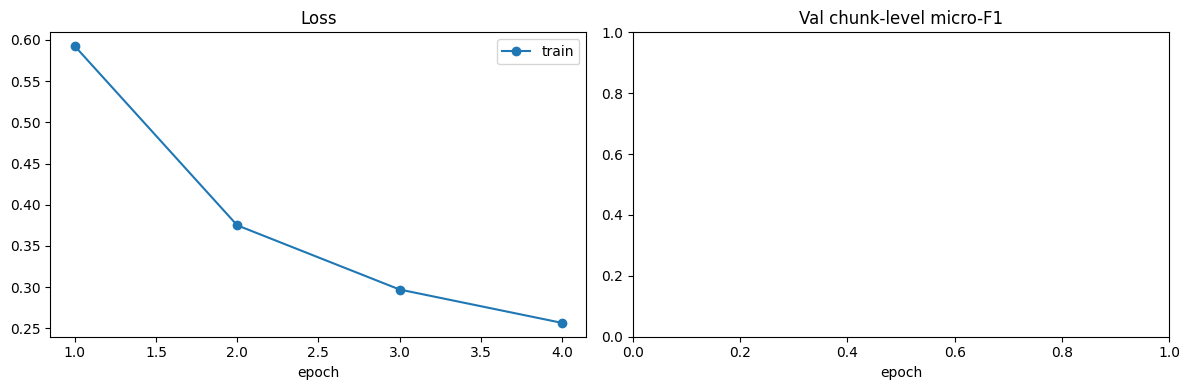

In [14]:
# Sanity check: training curve should climb monotonically
import matplotlib.pyplot as plt

hist = artifacts.history
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
if 'train_loss' in hist.columns:
    ax[0].plot(hist['epoch'], hist['train_loss'], marker='o', label='train')
if 'val_loss' in hist.columns:
    ax[0].plot(hist['epoch'], hist['val_loss'],   marker='o', label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('epoch'); ax[0].legend()
if 'val_micro_f1' in hist.columns:
    ax[1].plot(hist['epoch'], hist['val_micro_f1'], marker='o', color='C2')
ax[1].set_title('Val chunk-level micro-F1'); ax[1].set_xlabel('epoch')
plt.tight_layout(); plt.show()

## Section 3 — Max-pool chunks → contract-level probabilities

Chunk-level F1 is optimistic: every chunk has the contract's label, so a model can get decent F1 by learning "if the contract contains this clause, this chunk contains it too". What matters for the webapp is **contract-level** F1: does the contract contain the clause at all?

Max-pool gives us that: if *any* chunk scores high for a clause, the contract is flagged. Uses the existing `aggregate_contract_predictions` helper.

In [15]:
import numpy as np, pandas as pd
# from preprocessing import aggregate_contract_predictions

def _sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

id_to_clause = splits['id_to_clause']
clause_to_id = splits['clause_to_id']
val_examples = splits['val_examples']
val_records  = splits['val_records']

val_probs = _sigmoid(artifacts.val_logits)           # [n_chunks, n_labels]
print('val_probs shape:', val_probs.shape)

# Build long-format chunk DataFrame
rows = []
for chunk_idx, ex in enumerate(val_examples):
    for clause_id in range(val_probs.shape[1]):
        rows.append({
            'contract_title': ex['contract_title'],
            'clause_type':    id_to_clause[clause_id],
            'score':          float(val_probs[chunk_idx, clause_id]),
            'chunk_index':    ex['chunk_index'],
        })
chunk_long_df = pd.DataFrame(rows)
print('chunk_long_df:', chunk_long_df.shape)

# Max-pool per (contract, clause)
contract_preds = aggregate_contract_predictions(chunk_long_df)
print('contract_preds:', contract_preds.shape)

val_probs shape: (1390, 38)
chunk_long_df: (52820, 4)
contract_preds: (1938, 4)


In [16]:
# Pivot to [n_contracts, n_labels] probability matrix + build labels
contract_titles = [r['contract_title'] for r in val_records]
clause_cols     = [id_to_clause[i] for i in range(len(id_to_clause))]

pivot = (
    contract_preds
    .pivot(index='contract_title', columns='clause_type', values='max_score')
    .reindex(index=contract_titles, columns=clause_cols)
    .fillna(0.0)
)
contract_probs  = pivot.values
contract_logits = np.log(np.clip(contract_probs, 1e-7, 1-1e-7) / np.clip(1 - contract_probs, 1e-7, 1-1e-7))

contract_labels = np.zeros((len(val_records), len(id_to_clause)), dtype=int)
for i, rec in enumerate(val_records):
    for clause_name in rec['clause_spans']:
        if clause_name in clause_to_id:
            contract_labels[i, clause_to_id[clause_name]] = 1

print('contract_probs:', contract_probs.shape)
print('contract_labels:', contract_labels.shape, 'positives:', contract_labels.sum())

contract_probs: (51, 38)
contract_labels: (51, 38) positives: 704


## Section 4 — Per-clause thresholds + final metrics

In [17]:
from __future__ import annotations

import numpy as np
import pandas as pd
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)


def _sigmoid(logits: np.ndarray) -> np.ndarray:
    """Numerically stable sigmoid."""
    return 1.0 / (1.0 + np.exp(-np.clip(logits, -500, 500)))


def precision_at_recall_threshold(
    y_true: np.ndarray,
    y_score: np.ndarray,
    recall_target: float = 0.80,
) -> float:
    """Precision at the highest threshold that achieves recall >= recall_target.

    Returns 0.0 if the class has no positives or recall_target is unreachable.
    """
    if y_true.sum() == 0:
        return 0.0
    precision, recall, _ = precision_recall_curve(y_true, y_score)
    mask = recall >= recall_target
    if not mask.any():
        return 0.0
    return float(precision[mask].max())


def tune_per_clause_thresholds(
    logits: np.ndarray,
    labels: np.ndarray,
    id_to_clause: dict[int, str],
    thresholds: np.ndarray | None = None,
) -> dict[str, float]:
    """Find the threshold per clause that maximises per-clause F1 on the given logits.

    Returns dict mapping clause_name -> best_threshold (between 0 and 1).
    """
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.05)
    probs = _sigmoid(logits)
    best: dict[str, float] = {}

    for clause_id, clause_name in id_to_clause.items():
        y_true = labels[:, clause_id].astype(int)
        y_score = probs[:, clause_id]
        best_f1 = -1.0
        best_t = 0.5
        for t in thresholds:
            preds = (y_score >= t).astype(int)
            f1 = f1_score(y_true, preds, zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_t = float(t)
        best[clause_name] = best_t
    return best


def compute_aggregate_metrics(
    logits: np.ndarray,
    labels: np.ndarray,
    thresholds: dict[int | str, float],
    id_to_clause: dict[int, str] | None = None,
) -> dict[str, float]:
    """Macro/micro F1, precision, recall using per-clause thresholds.

    thresholds keys may be clause_name (str) or clause_id (int).
    """
    probs = _sigmoid(logits)
    num_labels = logits.shape[1]
    preds = np.zeros_like(probs, dtype=int)

    for i in range(num_labels):
        key = id_to_clause[i] if (id_to_clause and i in id_to_clause) else i
        t = thresholds.get(key, 0.5)
        preds[:, i] = (probs[:, i] >= t).astype(int)

    int_labels = labels.astype(int)
    return {
        "macro_f1":        float(f1_score(int_labels, preds, average="macro",  zero_division=0)),
        "micro_f1":        float(f1_score(int_labels, preds, average="micro",  zero_division=0)),
        "micro_precision": float(precision_score(int_labels, preds, average="micro", zero_division=0)),
        "micro_recall":    float(recall_score(int_labels, preds, average="micro",    zero_division=0)),
    }


def compute_per_clause_metrics(
    logits: np.ndarray,
    labels: np.ndarray,
    thresholds: dict[str, float],
    id_to_clause: dict[int, str],
    n_positive_train: dict[int, int],
) -> pd.DataFrame:
    """Per-clause breakdown: precision, recall, F1, P@80R, AUPR, threshold, n_positive_train.

    Returns a DataFrame sorted by F1 descending with one row per clause type.
    """
    probs = _sigmoid(logits)
    rows = []
    for clause_id, clause_name in id_to_clause.items():
        y_true = labels[:, clause_id].astype(int)
        y_score = probs[:, clause_id]
        t = thresholds.get(clause_name, 0.5)
        preds = (y_score >= t).astype(int)

        rows.append({
            "clause_type":            clause_name,
            "threshold":              round(t, 2),
            "precision":              float(precision_score(y_true, preds, zero_division=0)),
            "recall":                 float(recall_score(y_true, preds, zero_division=0)),
            "f1":                     float(f1_score(y_true, preds, zero_division=0)),
            "precision_at_80_recall": precision_at_recall_threshold(y_true, y_score, 0.80),
            "aupr":                   float(average_precision_score(y_true, y_score)) if y_true.sum() > 0 else 0.0,
            "support_test":           int(y_true.sum()),
            "n_positive_train":       n_positive_train.get(clause_id, 0),
        })
    return pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)


def plot_confusion_matrix(
    logits: np.ndarray,
    labels: np.ndarray,
    thresholds: dict[str, float],
    id_to_clause: dict[int, str],
    title: str = "Predicted vs True Clause Co-occurrence",
    save_path: str | None = None,
) -> None:
    """Heatmap: for each true-positive clause (row), what rate is each clause predicted (col)?

    Rows are indexed by true positive samples for each clause. Values show prediction rates.
    """
    import matplotlib.pyplot as plt
    import seaborn as sns

    probs = _sigmoid(logits)
    num_labels = logits.shape[1]
    clause_names = [id_to_clause[i] for i in range(num_labels)]
    preds = np.zeros_like(probs, dtype=int)
    for i in range(num_labels):
        t = thresholds.get(clause_names[i], 0.5)
        preds[:, i] = (probs[:, i] >= t).astype(int)

    int_labels = labels.astype(int)
    matrix = np.zeros((num_labels, num_labels), dtype=float)
    for true_idx in range(num_labels):
        true_positive_mask = int_labels[:, true_idx] == 1
        if true_positive_mask.sum() == 0:
            continue
        for pred_idx in range(num_labels):
            matrix[true_idx, pred_idx] = preds[true_positive_mask, pred_idx].mean()

    short_names = [n[:20] for n in clause_names]
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(
        matrix,
        xticklabels=short_names,
        yticklabels=short_names,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        ax=ax,
        cbar_kws={"label": "Rate predicted positive"},
    )
    ax.set_xlabel("Predicted clause")
    ax.set_ylabel("True clause (positive samples only)")
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")
    else:
        plt.show()


def plot_model_comparison(
    results: dict[str, pd.DataFrame],
    metric: str = "f1",
    save_path: str | None = None,
) -> None:
    """Grouped bar chart: all models x clause types for a given metric column."""
    if not results:
        raise ValueError("results dict is empty — nothing to plot")

    import matplotlib.pyplot as plt

    model_names = list(results.keys())
    combined = None
    for model_name, df in results.items():
        sub = df[["clause_type", metric]].rename(columns={metric: model_name})
        combined = sub if combined is None else combined.merge(sub, on="clause_type", how="outer")

    combined = combined.set_index("clause_type").fillna(0)
    combined.plot(kind="barh", figsize=(14, 10), colormap="tab10")
    plt.xlabel(metric.upper())
    plt.title(f"Per-Clause {metric.upper()} — All Models")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    else:
        plt.show()


In [18]:
# from evaluation import tune_per_clause_thresholds, compute_aggregate_metrics, compute_per_clause_metrics

# Per-clause thresholds tuned on val (for V1-V7 parity)
per_clause_thr = tune_per_clause_thresholds(contract_logits, contract_labels, id_to_clause)

metrics_v8 = compute_aggregate_metrics(
    contract_logits, contract_labels,
    thresholds=per_clause_thr,
    id_to_clause=id_to_clause,
)
print('=== V8 contract-level metrics (per-clause thresholds) ===')
for k, v in metrics_v8.items():
    print(f'  {k:18s} {v:.4f}')

# Also try a single global threshold for comparison
thresh_grid = np.arange(0.05, 0.96, 0.05)
best_global_f1, best_global_t = -1.0, 0.5
from sklearn.metrics import f1_score
for t in thresh_grid:
    preds = (contract_probs >= t).astype(int)
    f1 = f1_score(contract_labels, preds, average='micro', zero_division=0)
    if f1 > best_global_f1:
        best_global_f1, best_global_t = float(f1), float(t)
print(f'\nBest global-threshold micro-F1: {best_global_f1:.4f} at t={best_global_t:.2f}')

=== V8 contract-level metrics (per-clause thresholds) ===
  macro_f1           0.7283
  micro_f1           0.8047
  micro_precision    0.7175
  micro_recall       0.9162

Best global-threshold micro-F1: 0.7839 at t=0.90


In [19]:
# Per-clause breakdown
# n_positive_train needed for the per-clause metrics helper
train_labels = np.zeros((len(splits['train_records']), len(id_to_clause)), dtype=int)
for i, rec in enumerate(splits['train_records']):
    for clause_name in rec['clause_spans']:
        if clause_name in clause_to_id:
            train_labels[i, clause_to_id[clause_name]] = 1
n_positive_train = {i: int(train_labels[:, i].sum()) for i in range(len(id_to_clause))}

per_clause_df = compute_per_clause_metrics(
    contract_logits, contract_labels,
    thresholds=per_clause_thr,
    id_to_clause=id_to_clause,
    n_positive_train=n_positive_train,
)
per_clause_df.head(10)

,clause_type,threshold,precision,recall,f1,precision_at_80_recall,aupr,support_test,n_positive_train
0,Governing Law,0.75,1.000000,1.000000,1.000000,1.000000,1.000000,45,345
1,Document Name,0.05,1.000000,1.000000,1.000000,1.000000,1.000000,51,408
2,Parties,0.05,1.000000,1.000000,1.000000,1.000000,1.000000,51,407
3,Agreement Date,0.05,0.941176,1.000000,0.969697,0.959184,0.980944,48,379
4,Expiration Date,0.75,0.931818,1.000000,0.964706,0.973684,0.980009,41,329
5,Anti-Assignment,0.80,0.923077,0.972973,0.947368,0.971429,0.984915,37,297
6,Rofr/Rofo/Rofn,0.90,1.000000,0.900000,0.947368,1.000000,0.966667,10,72
7,Insurance,0.80,0.947368,0.947368,0.947368,1.000000,0.973170,19,130
8,Audit Rights,0.70,0.869565,1.000000,0.930233,0.947368,0.970336,20,173
9,Effective Date,0.55,0.860000,1.000000,0.924731,0.945946,0.926359,43,305


## Section 5 — Save artifacts, update ablation table, update chart

In [20]:
import joblib, os
from pathlib import Path

Path('checkpoints').mkdir(exist_ok=True)
ckpt_path = 'checkpoints/legal_bert_v8_artifacts.joblib'

payload = {
    'variant':          'V8 — Legal-BERT fine-tune',
    'model_state_dict': {k: v.detach().cpu() for k, v in artifacts.model.state_dict().items()},
    'tokenizer_name':   MODEL_NAME,
    'num_labels':       len(id_to_clause),
    'id_to_clause':     id_to_clause,
    'clause_to_id':     clause_to_id,
    'best_threshold':   per_clause_thr,     # dict {clause_name: threshold} — webapp-compatible
    'max_length':       512,
    'stride':           128,
    'val_metrics':      metrics_v8,
}
joblib.dump(payload, ckpt_path, compress=3)
print(f'Saved {ckpt_path} ({os.path.getsize(ckpt_path)/1e6:.1f} MB)')

Saved checkpoints/legal_bert_v8_artifacts.joblib (407.2 MB)


In [21]:
# Append V8 to the existing ablation table
Path('figures').mkdir(exist_ok=True)
ablation_path = 'figures/ablation_table.csv'

v1_f1 = 0.7936  # frozen baseline
v8_row = {
    'Variant':         'V8 — Legal-BERT fine-tune',
    'Micro-F1':        round(metrics_v8['micro_f1'], 4),
    'Macro-F1':        round(metrics_v8['macro_f1'], 4),
    'Micro-Precision': round(metrics_v8['micro_precision'], 4),
    'Micro-Recall':    round(metrics_v8['micro_recall'], 4),
    'Δ vs baseline':   round(metrics_v8['micro_f1'] - v1_f1, 4),
}

if os.path.exists(ablation_path):
    df = pd.read_csv(ablation_path)
    df = df[df['Variant'] != v8_row['Variant']]           # dedupe if rerun
    df = pd.concat([df, pd.DataFrame([v8_row])], ignore_index=True)
else:
    df = pd.DataFrame([v8_row])

df.to_csv(ablation_path, index=False)
df

,Variant,Micro-F1,Macro-F1,Micro-Precision,Micro-Recall,Δ vs baseline
0,V8 — Legal-BERT fine-tune,0.8047,0.7283,0.7175,0.9162,0.0111


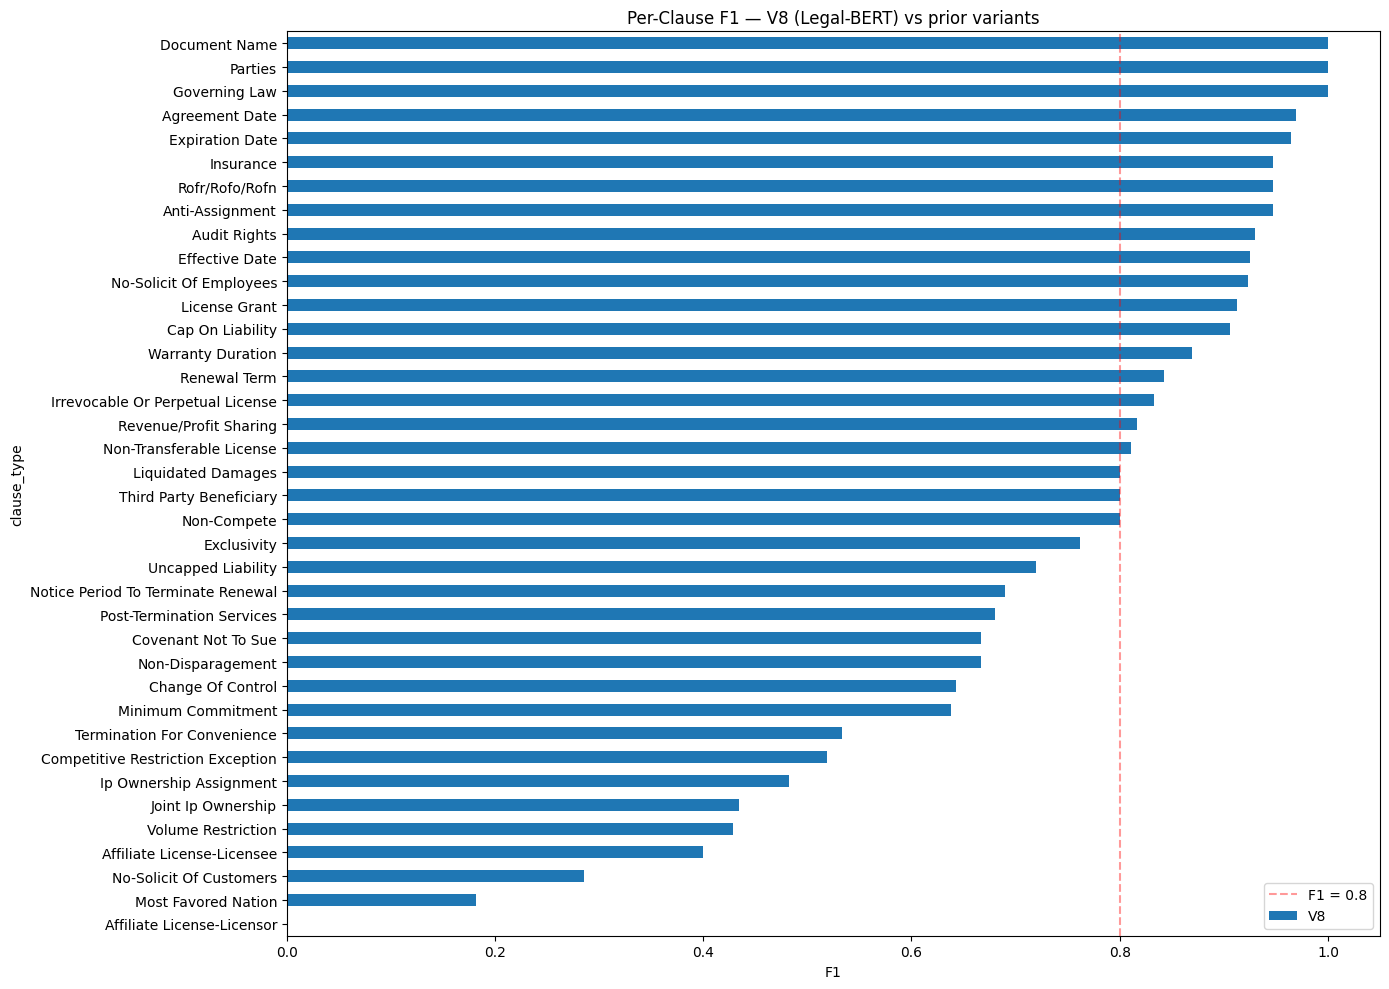

In [22]:
# Per-clause F1 chart: V1 vs V5 vs V8 (if V1/V5 per-clause files exist; otherwise V8 only)
import matplotlib.pyplot as plt

per_clause_v8 = per_clause_df[['clause_type', 'f1']].rename(columns={'f1': 'V8'})

# Optional: merge V1 + V5 per-clause F1 if they were persisted by performance_tuning.ipynb
joined = per_clause_v8.set_index('clause_type')
for prior in ('figures/per_clause_v1.csv', 'figures/per_clause_v5.csv'):
    if os.path.exists(prior):
        tag = Path(prior).stem.split('_')[-1].upper()
        d = pd.read_csv(prior)[['clause_type', 'f1']].rename(columns={'f1': tag}).set_index('clause_type')
        joined = joined.join(d, how='outer')
joined = joined.fillna(0.0).sort_values('V8', ascending=True)

fig, ax = plt.subplots(figsize=(14, 10))
joined.plot(kind='barh', ax=ax, colormap='tab10')
ax.set_xlabel('F1'); ax.set_title('Per-Clause F1 — V8 (Legal-BERT) vs prior variants')
ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.4, label='F1 = 0.8')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('figures/per_clause_f1_chart_v8.png', dpi=150, bbox_inches='tight')
plt.show()
per_clause_v8.to_csv('figures/per_clause_v8.csv', index=False)

## Section 6 — Download artifacts back to local machine

On Colab, download the checkpoint + figures to your laptop so you can swap it into the webapp.

In [ ]:
# Colab-only:
# from google.colab import files
# files.download('checkpoints/legal_bert_v8_artifacts.joblib')
# files.download('figures/ablation_table.csv')
# files.download('figures/per_clause_f1_chart_v8.png')
print('Done. Next steps:')
print('  1. Download legal_bert_v8_artifacts.joblib to your Mac')
print('  2. Back up: cp checkpoints/tfidf_lr_artifacts.joblib checkpoints/tfidf_lr_artifacts.V5.backup.joblib')
print('  3. Swap:    cp checkpoints/legal_bert_v8_artifacts.joblib checkpoints/tfidf_lr_artifacts.joblib')
print('  4. Run:     streamlit run webapp/app.py')